# AquaPlant — Phase H: Grad-CAM Explainability & Failure Analysis

This phase explains **where the two final CNNs focus when making predictions** and links visual explanations to the reliability results from Phases F–G.

## Models
- ResNet50 Fine-tuned
- EfficientNet-B0 Fine-tuned

## Required Kaggle inputs
Attach these four inputs:

1. **Aqua Plant Final Dataset**
2. **ResNet50** checkpoint dataset
3. **EfficientNetB0** checkpoint dataset
4. **AquaPlant Phase G Selective Prediction Artifacts** ZIP/dataset

## What this notebook produces
- Grad-CAM for high-confidence correct predictions
- Grad-CAM for low-confidence correct predictions
- Grad-CAM for high-confidence errors
- For errors: **predicted-class CAM vs true-class CAM**
- Complete error-case explanation sheets
- Descriptive CAM concentration measures
- Selected-case CSV
- Paper-ready PNG figures
- Final Phase-H artifact ZIP

### Important interpretation rule
Grad-CAM is an **explanation/attention visualization**, not proof of causal reasoning.  
Because this classification dataset does not provide localization masks for this evaluation, CAMs are interpreted qualitatively. We do **not** report localization accuracy.

In [4]:
# ============================================================
# CELL 1 — ENVIRONMENT
# ============================================================

import os
import re
import json
import math
import random
import zipfile
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageDraw

import torch
import torch.nn as nn
import torch.nn.functional as F

from torchvision import datasets, transforms
from torchvision.models import resnet50, efficientnet_b0

from IPython.display import display

warnings.filterwarnings("ignore")

SEED = 42
IMG_SIZE = 224
NUM_CLASSES = 14

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

IMAGENET_MEAN = [
    0.485,
    0.456,
    0.406
]

IMAGENET_STD = [
    0.229,
    0.224,
    0.225
]

MODEL_NAMES = [
    "ResNet50_Finetuned",
    "EfficientNetB0_Finetuned",
]

print("=" * 78)
print("PHASE H — GRAD-CAM EXPLAINABILITY")
print("=" * 78)

print("PyTorch :", torch.__version__)
print("CUDA    :", torch.cuda.is_available())
print("Device  :", DEVICE)

if torch.cuda.is_available():
    print("GPU     :", torch.cuda.get_device_name(0))

print("\nKaggle inputs:")
for item in os.listdir("/kaggle/input"):
    print(" -", item)

print("\n✅ Phase H environment ready")
print("✅ No training or hyperparameter tuning will be performed")


PHASE H — GRAD-CAM EXPLAINABILITY
PyTorch : 2.10.0+cu128
CUDA    : True
Device  : cuda
GPU     : Tesla T4

Kaggle inputs:
 - datasets

✅ Phase H environment ready
✅ No training or hyperparameter tuning will be performed


In [5]:
# ============================================================
# CELL 2 — FIND TEST SET + MODEL CHECKPOINTS
# ============================================================

IMAGE_EXTENSIONS = (
    ".jpg", ".jpeg", ".png",
    ".bmp", ".tif", ".tiff", ".webp"
)

def count_images_recursive(folder):
    total = 0

    for root, dirs, files in os.walk(folder):
        total += sum(
            1 for file in files
            if file.lower().endswith(IMAGE_EXTENSIONS)
        )

    return total

def count_direct_folders(folder):
    try:
        return len([
            d for d in os.listdir(folder)
            if os.path.isdir(
                os.path.join(folder, d)
            )
        ])
    except Exception:
        return 0

TEST_DIR = None

for root, dirs, files in os.walk("/kaggle/input"):
    if count_direct_folders(root) == 14:
        if count_images_recursive(root) == 157:
            TEST_DIR = root
            break

ALL_FILES = []

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        ALL_FILES.append(
            os.path.join(root, file)
        )

def find_checkpoint(model_word):
    candidates = []

    for path in ALL_FILES:
        name = os.path.basename(path).lower()

        if not name.endswith(".pth"):
            continue

        if (
            model_word.lower() in name
            and "finetuned" in name
            and "best" in name
        ):
            candidates.append(path)

    return candidates[0] if candidates else None

RESNET_PTH = find_checkpoint("resnet50")
EFFNET_PTH = find_checkpoint("efficientnet")

print("=" * 78)
print("RESOURCE DETECTION")
print("=" * 78)

print("\nLocked Test:")
print(TEST_DIR)

print("\nResNet50 Fine-tuned:")
print(RESNET_PTH)

print("\nEfficientNet-B0 Fine-tuned:")
print(EFFNET_PTH)

assert TEST_DIR is not None, \
    "❌ Test folder with 157 images was not found."

assert RESNET_PTH is not None, \
    "❌ ResNet50 fine-tuned checkpoint was not found."

assert EFFNET_PTH is not None, \
    "❌ EfficientNet-B0 fine-tuned checkpoint was not found."

print("\n✅ Test = 157 images")
print("✅ Both fine-tuned checkpoints found")


RESOURCE DETECTION

Locked Test:
/kaggle/input/datasets/srabondcosta/aqua-plant-final-dataset/AquPlantDS_FINAL/Test

ResNet50 Fine-tuned:
/kaggle/input/datasets/srabondcosta/resnet50/resnet50_finetuned_best.pth

EfficientNet-B0 Fine-tuned:
/kaggle/input/datasets/srabondcosta/efficientnetb0/efficientnet_b0_finetuned_best.pth

✅ Test = 157 images
✅ Both fine-tuned checkpoints found


In [6]:
# ============================================================
# CELL 3 — FIND / EXTRACT PHASE-G PER-IMAGE SCORES
# ============================================================

def collect_files(root):
    found = []

    for current_root, dirs, files in os.walk(root):
        for file in files:
            found.append(
                os.path.join(current_root, file)
            )

    return found

def find_phaseg_score_csv(model_name, files):
    target = (
        f"phaseG_{model_name}_"
        "per_image_scores.csv"
    ).lower()

    for path in files:
        if os.path.basename(path).lower() == target:
            return path

    return None

PHASEG_FILES = collect_files("/kaggle/input")

RESNET_SCORE_CSV = find_phaseg_score_csv(
    "ResNet50_Finetuned",
    PHASEG_FILES
)

EFFNET_SCORE_CSV = find_phaseg_score_csv(
    "EfficientNetB0_Finetuned",
    PHASEG_FILES
)

# ZIP fallback
if (
    RESNET_SCORE_CSV is None
    or EFFNET_SCORE_CSV is None
):
    EXTRACT_ROOT = (
        "/kaggle/working/"
        "phaseH_phaseG_extracted"
    )

    os.makedirs(
        EXTRACT_ROOT,
        exist_ok=True
    )

    for zip_path in [
        p for p in PHASEG_FILES
        if p.lower().endswith(".zip")
    ]:
        try:
            with zipfile.ZipFile(zip_path, "r") as z:
                names = [
                    n.lower()
                    for n in z.namelist()
                ]

                is_phaseg = any(
                    "phaseg_" in n
                    and "per_image_scores.csv" in n
                    for n in names
                )

                if not is_phaseg:
                    continue

                target_dir = os.path.join(
                    EXTRACT_ROOT,
                    Path(zip_path).stem
                )

                os.makedirs(
                    target_dir,
                    exist_ok=True
                )

                z.extractall(
                    target_dir
                )

        except Exception:
            pass

    PHASEG_FILES.extend(
        collect_files(EXTRACT_ROOT)
    )

    RESNET_SCORE_CSV = (
        RESNET_SCORE_CSV
        or find_phaseg_score_csv(
            "ResNet50_Finetuned",
            PHASEG_FILES
        )
    )

    EFFNET_SCORE_CSV = (
        EFFNET_SCORE_CSV
        or find_phaseg_score_csv(
            "EfficientNetB0_Finetuned",
            PHASEG_FILES
        )
    )

print("=" * 78)
print("PHASE-G SCORE DETECTION")
print("=" * 78)

print("\nResNet50 scores:")
print(RESNET_SCORE_CSV)

print("\nEfficientNet-B0 scores:")
print(EFFNET_SCORE_CSV)

assert RESNET_SCORE_CSV is not None, \
    "❌ ResNet50 Phase-G per-image scores not found."

assert EFFNET_SCORE_CSV is not None, \
    "❌ EfficientNet-B0 Phase-G per-image scores not found."

print("\n✅ Both Phase-G score tables found")


PHASE-G SCORE DETECTION

ResNet50 scores:
/kaggle/input/datasets/srabondcosta/aquatic-phase-g/phaseG_ResNet50_Finetuned_per_image_scores.csv

EfficientNet-B0 scores:
/kaggle/input/datasets/srabondcosta/aquatic-phase-g/phaseG_EfficientNetB0_Finetuned_per_image_scores.csv

✅ Both Phase-G score tables found


In [7]:
# ============================================================
# CELL 4 — TEST DATASET + CLASS MAPPING
# ============================================================

eval_transform = transforms.Compose([
    transforms.Resize(
        (IMG_SIZE, IMG_SIZE)
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    ),
])

test_dataset = datasets.ImageFolder(
    TEST_DIR,
    transform=eval_transform
)

CLASS_NAMES = test_dataset.classes

assert len(test_dataset) == 157
assert len(CLASS_NAMES) == 14

print("=" * 78)
print("TEST SET")
print("=" * 78)

print("Images  :", len(test_dataset))
print("Classes :", len(CLASS_NAMES))

print("\nClass mapping:")

for cls, idx in test_dataset.class_to_idx.items():
    print(f"{idx:2d} -> {cls}")

with open(
    "/kaggle/working/"
    "phaseH_class_mapping.json",
    "w"
) as f:
    json.dump(
        test_dataset.class_to_idx,
        f,
        indent=2
    )

print("\n✅ Test set ready")


TEST SET
Images  : 157
Classes : 14

Class mapping:
 0 -> Class_10_lippia_alba
 1 -> Class_11_marsilea_minuta
 2 -> Class_12_duck_weeds
 3 -> Class_13_topapana
 4 -> Class_14_kachuripana
 5 -> Class_1_water_iris
 6 -> Class_2_pistia_stratiotes
 7 -> Class_3_lily_leaf
 8 -> Class_4_lotus-leaf
 9 -> Class_5_water_popy
10 -> Class_6_salvania
11 -> Class_7_chinese_water_spinach
12 -> Class_8_water_plantain
13 -> Class_9_mexican_sword_lily

✅ Test set ready


In [8]:
# ============================================================
# CELL 5 — EXACT MODEL ARCHITECTURES + CHECKPOINT LOADERS
# ============================================================

def safe_torch_load(
    path,
    map_location="cpu"
):
    try:
        return torch.load(
            path,
            map_location=map_location,
            weights_only=False
        )
    except TypeError:
        return torch.load(
            path,
            map_location=map_location
        )

def extract_state_dict(checkpoint):
    if not isinstance(
        checkpoint,
        dict
    ):
        return checkpoint

    for key in [
        "model_state_dict",
        "state_dict",
        "model",
        "weights",
    ]:
        if (
            key in checkpoint
            and isinstance(
                checkpoint[key],
                dict
            )
        ):
            return checkpoint[key]

    if all(
        isinstance(k, str)
        for k in checkpoint.keys()
    ):
        if any(
            k.endswith(".weight")
            or k.endswith(".bias")
            for k in checkpoint.keys()
        ):
            return checkpoint

    raise RuntimeError(
        "Could not identify state_dict."
    )

def remove_module_prefix(state_dict):
    clean = {}

    for key, value in state_dict.items():
        if key.startswith("module."):
            key = key[
                len("module.") :
            ]

        clean[key] = value

    return clean

def build_resnet50():
    model = resnet50(
        weights=None
    )

    in_features = (
        model.fc.in_features
    )

    model.fc = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(
            in_features,
            NUM_CLASSES
        )
    )

    return model

def build_efficientnet_b0():
    model = efficientnet_b0(
        weights=None
    )

    in_features = (
        model.classifier[1]
        .in_features
    )

    model.classifier = nn.Sequential(
        nn.Dropout(
            p=0.3,
            inplace=True
        ),
        nn.Linear(
            in_features,
            NUM_CLASSES
        )
    )

    return model

def load_model(
    model,
    checkpoint_path
):
    checkpoint = safe_torch_load(
        checkpoint_path,
        map_location=DEVICE
    )

    state_dict = extract_state_dict(
        checkpoint
    )

    state_dict = remove_module_prefix(
        state_dict
    )

    model.load_state_dict(
        state_dict,
        strict=True
    )

    model = model.to(
        DEVICE
    )

    model.eval()

    return model

resnet_model = load_model(
    build_resnet50(),
    RESNET_PTH
)

effnet_model = load_model(
    build_efficientnet_b0(),
    EFFNET_PTH
)

MODEL_OBJECTS = {
    "ResNet50_Finetuned":
        resnet_model,

    "EfficientNetB0_Finetuned":
        effnet_model,
}

TARGET_LAYERS = {
    "ResNet50_Finetuned":
        resnet_model.layer4[-1],

    "EfficientNetB0_Finetuned":
        effnet_model.features[-1],
}

print("✅ ResNet50 loaded")
print("✅ EfficientNet-B0 loaded")
print("✅ Grad-CAM target layers registered")


✅ ResNet50 loaded
✅ EfficientNet-B0 loaded
✅ Grad-CAM target layers registered


In [9]:
# ============================================================
# CELL 6 — LOAD PHASE-G SCORES + MAP TO CURRENT TEST PATHS
# ============================================================

phaseG_scores = {
    "ResNet50_Finetuned":
        pd.read_csv(
            RESNET_SCORE_CSV
        ),

    "EfficientNetB0_Finetuned":
        pd.read_csv(
            EFFNET_SCORE_CSV
        ),
}

def normalized_suffix(path):
    p = Path(
        str(path).replace(
            "\\",
            "/"
        )
    )

    parts = p.parts

    if len(parts) >= 2:
        return (
            f"{parts[-2]}/"
            f"{parts[-1]}"
        ).lower()

    return str(p).lower()

current_path_map = {}

for current_path, label in test_dataset.samples:
    key = normalized_suffix(
        current_path
    )

    current_path_map[
        key
    ] = current_path

for model_name, df in phaseG_scores.items():
    required_columns = [
        "image_path",
        "true_index",
        "true_class",
        "pred_index",
        "pred_class",
        "correct",
        "calibrated_confidence",
        "predictive_entropy",
    ]

    missing = [
        col for col in required_columns
        if col not in df.columns
    ]

    assert not missing, \
        f"❌ {model_name}: missing columns {missing}"

    df = df.copy()

    # Robust boolean conversion.
    df["correct"] = (
        df["correct"]
        .astype(str)
        .str.lower()
        .map({
            "true": True,
            "false": False,
            "1": True,
            "0": False,
        })
    )

    assert df["correct"].notna().all()

    df["path_key"] = df[
        "image_path"
    ].apply(
        normalized_suffix
    )

    df["current_image_path"] = df[
        "path_key"
    ].map(
        current_path_map
    )

    missing_paths = int(
        df[
            "current_image_path"
        ].isna().sum()
    )

    assert missing_paths == 0, (
        f"❌ {model_name}: "
        f"{missing_paths} Phase-G paths "
        "could not be mapped to Test."
    )

    assert len(df) == 157

    phaseG_scores[
        model_name
    ] = df

    print("\n" + "=" * 78)
    print(model_name)
    print("=" * 78)

    print(
        "Rows              :",
        len(df)
    )

    print(
        "Correct           :",
        int(df["correct"].sum())
    )

    print(
        "Errors            :",
        int((~df["correct"]).sum())
    )

    print(
        "Mean confidence   :",
        f"{df['calibrated_confidence'].mean() * 100:.2f}%"
    )

print("\n✅ All Phase-G cases mapped to current Test files")



ResNet50_Finetuned
Rows              : 157
Correct           : 151
Errors            : 6
Mean confidence   : 96.13%

EfficientNetB0_Finetuned
Rows              : 157
Correct           : 150
Errors            : 7
Mean confidence   : 96.48%

✅ All Phase-G cases mapped to current Test files


In [10]:
# ============================================================
# CELL 7 — SELECT EXPLANATION CASES
# ============================================================

def select_explanation_cases(
    df,
    model_name
):
    correct_df = (
        df[df["correct"]]
        .copy()
    )

    error_df = (
        df[~df["correct"]]
        .copy()
    )

    selected_parts = []

    # Two very confident correct cases.
    temp = (
        correct_df
        .sort_values(
            "calibrated_confidence",
            ascending=False
        )
        .head(2)
        .copy()
    )

    temp[
        "case_type"
    ] = "High-confidence correct"

    selected_parts.append(
        temp
    )

    # Two uncertain but still correct cases.
    temp = (
        correct_df
        .sort_values(
            "calibrated_confidence",
            ascending=True
        )
        .head(2)
        .copy()
    )

    temp[
        "case_type"
    ] = "Low-confidence correct"

    selected_parts.append(
        temp
    )

    # Two most dangerous mistakes:
    # wrong but highest calibrated confidence.
    temp = (
        error_df
        .sort_values(
            "calibrated_confidence",
            ascending=False
        )
        .head(2)
        .copy()
    )

    temp[
        "case_type"
    ] = "High-confidence error"

    selected_parts.append(
        temp
    )

    selected = pd.concat(
        selected_parts,
        ignore_index=True
    )

    selected.insert(
        0,
        "Model",
        model_name
    )

    selected.insert(
        1,
        "case_number",
        np.arange(
            1,
            len(selected) + 1
        )
    )

    return selected

selected_cases = []

for model_name, df in phaseG_scores.items():
    selected_cases.append(
        select_explanation_cases(
            df,
            model_name
        )
    )

selected_cases_df = pd.concat(
    selected_cases,
    ignore_index=True
)

SELECTED_CASES_PATH = (
    "/kaggle/working/"
    "phaseH_selected_cases.csv"
)

selected_cases_df.to_csv(
    SELECTED_CASES_PATH,
    index=False
)

display(
    selected_cases_df[
        [
            "Model",
            "case_number",
            "case_type",
            "true_class",
            "pred_class",
            "calibrated_confidence",
            "predictive_entropy",
        ]
    ].round(6)
)

print("\n✅ Saved:", SELECTED_CASES_PATH)


,Model,case_number,case_type,true_class,pred_class,calibrated_confidence,predictive_entropy
0,ResNet50_Finetuned,1,High-confidence correct,Class_12_duck_weeds,Class_12_duck_weeds,1.000000,0.000003
1,ResNet50_Finetuned,2,High-confidence correct,Class_3_lily_leaf,Class_3_lily_leaf,1.000000,0.000000
2,ResNet50_Finetuned,3,Low-confidence correct,Class_10_lippia_alba,Class_10_lippia_alba,0.378251,1.687139
3,ResNet50_Finetuned,4,Low-confidence correct,Class_11_marsilea_minuta,Class_11_marsilea_minuta,0.543434,1.123844
4,ResNet50_Finetuned,5,High-confidence error,Class_10_lippia_alba,Class_7_chinese_water_spinach,0.989679,0.062557
5,ResNet50_Finetuned,6,High-confidence error,Class_7_chinese_water_spinach,Class_1_water_iris,0.775157,0.618562
6,EfficientNetB0_Finetuned,1,High-confidence correct,Class_5_water_popy,Class_5_water_popy,1.000000,0.000004
7,EfficientNetB0_Finetuned,2,High-confidence correct,Class_10_lippia_alba,Class_10_lippia_alba,0.999999,0.000015
8,EfficientNetB0_Finetuned,3,Low-confidence correct,Class_14_kachuripana,Class_14_kachuripana,0.301051,1.810146
9,EfficientNetB0_Finetuned,4,Low-confidence correct,Class_11_marsilea_minuta,Class_11_marsilea_minuta,0.623533,1.159644



✅ Saved: /kaggle/working/phaseH_selected_cases.csv


In [11]:
# ============================================================
# CELL 8 — GRAD-CAM IMPLEMENTATION
# No external Grad-CAM package required
# ============================================================

class GradCAM:
    def __init__(
        self,
        model,
        target_layer
    ):
        self.model = model
        self.target_layer = target_layer
        self.activations = None

        self.handle = (
            self.target_layer
            .register_forward_hook(
                self._forward_hook
            )
        )

    def _forward_hook(
        self,
        module,
        inputs,
        output
    ):
        self.activations = output

    def generate(
        self,
        input_tensor,
        target_class=None
    ):
        self.model.eval()

        self.model.zero_grad(
            set_to_none=True
        )

        logits = self.model(
            input_tensor
        )

        predicted_class = int(
            logits.argmax(
                dim=1
            ).item()
        )

        if target_class is None:
            target_class = (
                predicted_class
            )

        score = logits[
            0,
            int(target_class)
        ]

        gradients = torch.autograd.grad(
            outputs=score,
            inputs=self.activations,
            retain_graph=False,
            create_graph=False
        )[0]

        activations = (
            self.activations
            .detach()
        )

        gradients = (
            gradients
            .detach()
        )

        weights = gradients.mean(
            dim=(2, 3),
            keepdim=True
        )

        cam = (
            weights
            * activations
        ).sum(
            dim=1,
            keepdim=True
        )

        cam = F.relu(
            cam
        )

        cam = F.interpolate(
            cam,
            size=input_tensor.shape[-2:],
            mode="bilinear",
            align_corners=False
        )

        cam = cam[
            0,
            0
        ].detach().cpu().numpy()

        cam = (
            cam
            - cam.min()
        )

        max_value = cam.max()

        if max_value > 0:
            cam = (
                cam
                / max_value
            )

        probabilities = (
            torch.softmax(
                logits.detach(),
                dim=1
            )
            .cpu()
            .numpy()[0]
        )

        return {
            "cam":
                cam,

            "logits":
                logits.detach().cpu().numpy()[0],

            "probabilities":
                probabilities,

            "predicted_class":
                predicted_class,

            "target_class":
                int(target_class),
        }

    def close(self):
        self.handle.remove()

GRADCAM_OBJECTS = {
    model_name:
        GradCAM(
            MODEL_OBJECTS[
                model_name
            ],
            TARGET_LAYERS[
                model_name
            ]
        )
    for model_name in MODEL_NAMES
}

print("✅ Grad-CAM engine ready")


✅ Grad-CAM engine ready


In [12]:
# ============================================================
# CELL 9 — VISUALIZATION + CAM DESCRIPTIVE METRICS
# ============================================================

def prepare_image_tensor(
    image_path
):
    pil_image = (
        Image.open(
            image_path
        )
        .convert("RGB")
    )

    resized = pil_image.resize(
        (IMG_SIZE, IMG_SIZE)
    )

    tensor = eval_transform(
        pil_image
    ).unsqueeze(0).to(
        DEVICE
    )

    return (
        pil_image,
        resized,
        tensor
    )

def make_heatmap_rgb(cam):
    cmap = plt.get_cmap(
        "turbo"
    )

    heatmap = cmap(
        np.clip(
            cam,
            0,
            1
        )
    )[
        ...,
        :3
    ]

    return heatmap

def make_overlay(
    resized_pil,
    cam,
    alpha=0.45
):
    image_np = (
        np.asarray(
            resized_pil
        )
        .astype(
            np.float32
        )
        / 255.0
    )

    heatmap = make_heatmap_rgb(
        cam
    )

    overlay = (
        (1.0 - alpha)
        * image_np
        + alpha
        * heatmap
    )

    overlay = np.clip(
        overlay,
        0,
        1
    )

    return Image.fromarray(
        (
            overlay
            * 255
        ).astype(
            np.uint8
        )
    )

def cam_concentration_50(cam):
    flat = np.clip(
        cam.reshape(-1),
        0,
        None
    )

    total = float(
        flat.sum()
    )

    if total <= 0:
        return np.nan

    ordered = np.sort(
        flat
    )[::-1]

    cumulative = np.cumsum(
        ordered
    )

    k = int(
        np.searchsorted(
            cumulative,
            0.50 * total
        )
        + 1
    )

    return (
        k / len(flat)
    )

def cam_peak_location(cam):
    y, x = np.unravel_index(
        np.argmax(cam),
        cam.shape
    )

    x_norm = (
        x / max(
            1,
            cam.shape[1] - 1
        )
    )

    y_norm = (
        y / max(
            1,
            cam.shape[0] - 1
        )
    )

    return (
        float(x_norm),
        float(y_norm)
    )

def sanitize_filename(text):
    text = re.sub(
        r"[^A-Za-z0-9_-]+",
        "_",
        str(text)
    )

    return text.strip("_")

def create_labeled_triptych(
    original,
    pred_overlay,
    true_overlay,
    title_text,
    pred_label,
    true_label
):
    panel_w = IMG_SIZE
    panel_h = IMG_SIZE
    header_h = 70

    canvas = Image.new(
        "RGB",
        (
            panel_w * 3,
            panel_h + header_h
        ),
        "white"
    )

    canvas.paste(
        original.resize(
            (IMG_SIZE, IMG_SIZE)
        ),
        (0, header_h)
    )

    canvas.paste(
        pred_overlay,
        (panel_w, header_h)
    )

    canvas.paste(
        true_overlay,
        (
            panel_w * 2,
            header_h
        )
    )

    draw = ImageDraw.Draw(
        canvas
    )

    draw.text(
        (8, 8),
        title_text,
        fill="black"
    )

    draw.text(
        (8, 32),
        "Original",
        fill="black"
    )

    draw.text(
        (panel_w + 8, 32),
        f"Predicted-target CAM: {pred_label}",
        fill="black"
    )

    draw.text(
        (
            panel_w * 2 + 8,
            32
        ),
        f"True-target CAM: {true_label}",
        fill="black"
    )

    return canvas

def create_labeled_pair(
    original,
    overlay,
    title_text,
    target_label
):
    panel_w = IMG_SIZE
    panel_h = IMG_SIZE
    header_h = 70

    canvas = Image.new(
        "RGB",
        (
            panel_w * 2,
            panel_h + header_h
        ),
        "white"
    )

    canvas.paste(
        original.resize(
            (IMG_SIZE, IMG_SIZE)
        ),
        (0, header_h)
    )

    canvas.paste(
        overlay,
        (panel_w, header_h)
    )

    draw = ImageDraw.Draw(
        canvas
    )

    draw.text(
        (8, 8),
        title_text,
        fill="black"
    )

    draw.text(
        (8, 32),
        "Original",
        fill="black"
    )

    draw.text(
        (panel_w + 8, 32),
        f"Predicted-class CAM: {target_label}",
        fill="black"
    )

    return canvas

print("✅ Visualization utilities ready")


✅ Visualization utilities ready


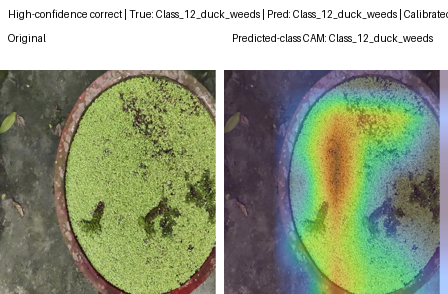

✅ Saved: /kaggle/working/phaseH_gradcam_figures/phaseH_ResNet50_Finetuned_case01_High-confidence_correct.png


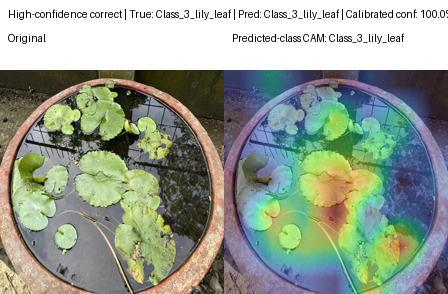

✅ Saved: /kaggle/working/phaseH_gradcam_figures/phaseH_ResNet50_Finetuned_case02_High-confidence_correct.png


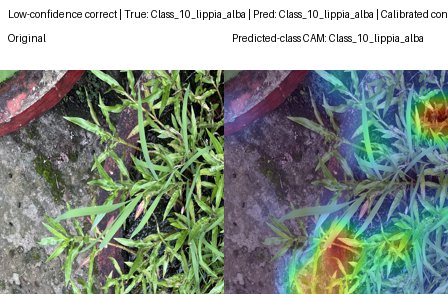

✅ Saved: /kaggle/working/phaseH_gradcam_figures/phaseH_ResNet50_Finetuned_case03_Low-confidence_correct.png


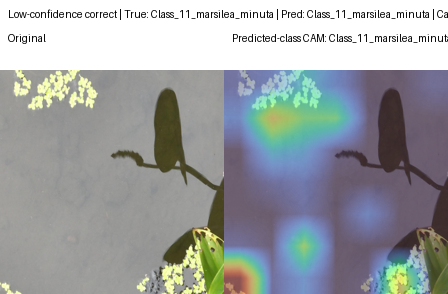

✅ Saved: /kaggle/working/phaseH_gradcam_figures/phaseH_ResNet50_Finetuned_case04_Low-confidence_correct.png


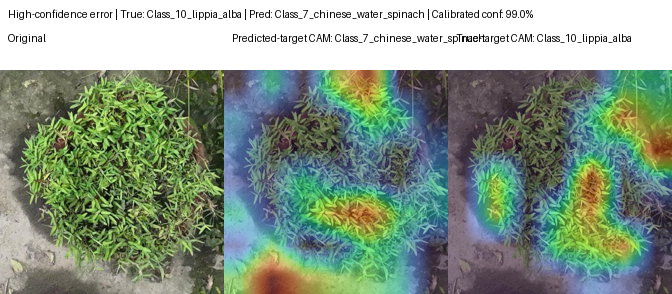

✅ Saved: /kaggle/working/phaseH_gradcam_figures/phaseH_ResNet50_Finetuned_case05_High-confidence_error.png


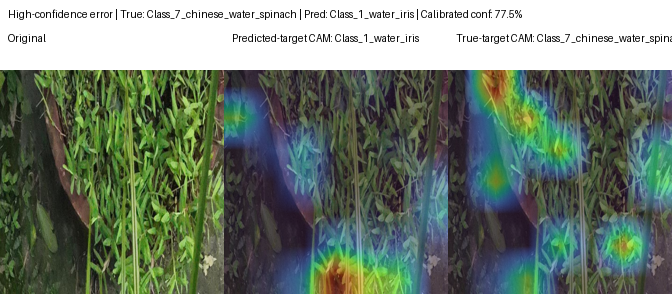

✅ Saved: /kaggle/working/phaseH_gradcam_figures/phaseH_ResNet50_Finetuned_case06_High-confidence_error.png


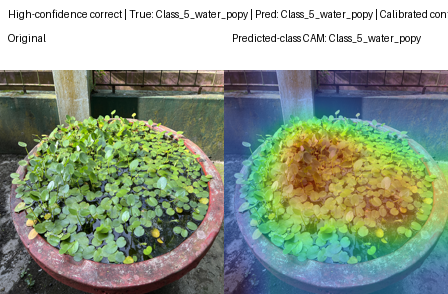

✅ Saved: /kaggle/working/phaseH_gradcam_figures/phaseH_EfficientNetB0_Finetuned_case01_High-confidence_correct.png


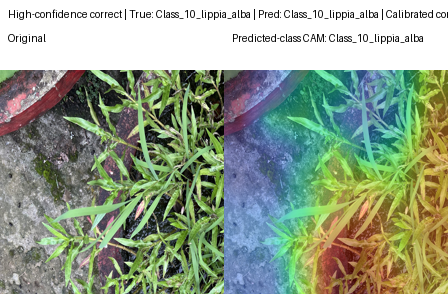

✅ Saved: /kaggle/working/phaseH_gradcam_figures/phaseH_EfficientNetB0_Finetuned_case02_High-confidence_correct.png


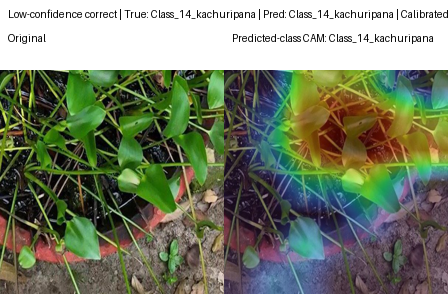

✅ Saved: /kaggle/working/phaseH_gradcam_figures/phaseH_EfficientNetB0_Finetuned_case03_Low-confidence_correct.png


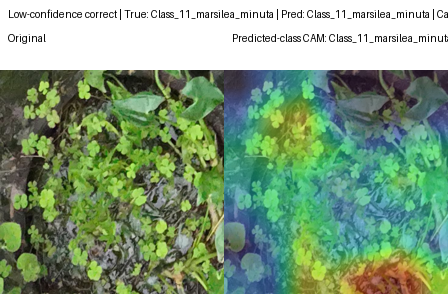

✅ Saved: /kaggle/working/phaseH_gradcam_figures/phaseH_EfficientNetB0_Finetuned_case04_Low-confidence_correct.png


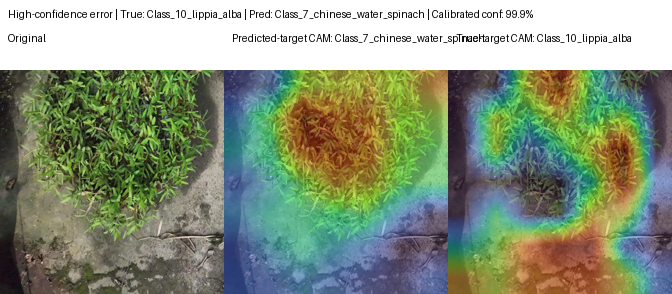

✅ Saved: /kaggle/working/phaseH_gradcam_figures/phaseH_EfficientNetB0_Finetuned_case05_High-confidence_error.png


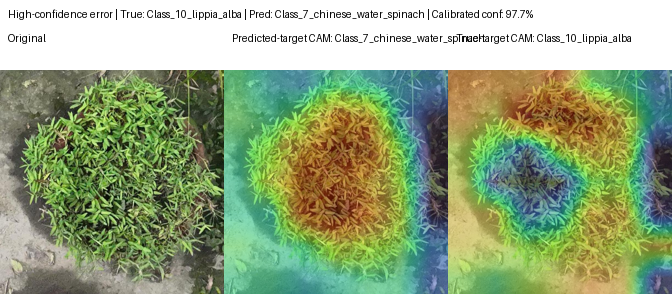

✅ Saved: /kaggle/working/phaseH_gradcam_figures/phaseH_EfficientNetB0_Finetuned_case06_High-confidence_error.png

✅ Selected-case Grad-CAM analysis complete
✅ Saved: /kaggle/working/phaseH_selected_case_cam_metrics.csv


In [13]:
# ============================================================
# CELL 10 — GENERATE SELECTED-CASE GRAD-CAM FIGURES
# ============================================================

OUTPUT_DIR = (
    "/kaggle/working/"
    "phaseH_gradcam_figures"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

cam_metric_rows = []
selected_figure_paths = []

for _, row in selected_cases_df.iterrows():
    model_name = row["Model"]

    model = MODEL_OBJECTS[
        model_name
    ]

    gradcam = GRADCAM_OBJECTS[
        model_name
    ]

    image_path = row[
        "current_image_path"
    ]

    (
        pil_original,
        resized,
        tensor
    ) = prepare_image_tensor(
        image_path
    )

    saved_pred_idx = int(
        row["pred_index"]
    )

    true_idx = int(
        row["true_index"]
    )

    # Predicted-class explanation.
    pred_result = gradcam.generate(
        tensor,
        target_class=saved_pred_idx
    )

    # Verify checkpoint + image produce
    # the same class as Phase G.
    assert (
        pred_result[
            "predicted_class"
        ]
        == saved_pred_idx
    ), (
        f"❌ Prediction mismatch for "
        f"{model_name}: {image_path}"
    )

    pred_cam = pred_result[
        "cam"
    ]

    pred_overlay = make_overlay(
        resized,
        pred_cam
    )

    pred_concentration = (
        cam_concentration_50(
            pred_cam
        )
    )

    pred_peak_x, pred_peak_y = (
        cam_peak_location(
            pred_cam
        )
    )

    is_correct = bool(
        row["correct"]
    )

    title_text = (
        f"{row['case_type']} | "
        f"True: {row['true_class']} | "
        f"Pred: {row['pred_class']} | "
        f"Calibrated conf: "
        f"{row['calibrated_confidence'] * 100:.1f}%"
    )

    if is_correct:
        figure = create_labeled_pair(
            resized,
            pred_overlay,
            title_text,
            row["pred_class"]
        )

        true_concentration = (
            pred_concentration
        )

        true_peak_x = pred_peak_x
        true_peak_y = pred_peak_y

    else:
        # Also explain the true class to compare
        # with the wrongly selected predicted class.
        true_result = gradcam.generate(
            tensor,
            target_class=true_idx
        )

        true_cam = true_result[
            "cam"
        ]

        true_overlay = make_overlay(
            resized,
            true_cam
        )

        true_concentration = (
            cam_concentration_50(
                true_cam
            )
        )

        true_peak_x, true_peak_y = (
            cam_peak_location(
                true_cam
            )
        )

        figure = create_labeled_triptych(
            resized,
            pred_overlay,
            true_overlay,
            title_text,
            row["pred_class"],
            row["true_class"]
        )

    filename = (
        f"phaseH_"
        f"{sanitize_filename(model_name)}_"
        f"case{int(row['case_number']):02d}_"
        f"{sanitize_filename(row['case_type'])}.png"
    )

    save_path = os.path.join(
        OUTPUT_DIR,
        filename
    )

    figure.save(
        save_path
    )

    selected_figure_paths.append(
        save_path
    )

    cam_metric_rows.append({
        "Model":
            model_name,

        "case_number":
            int(
                row["case_number"]
            ),

        "case_type":
            row["case_type"],

        "image_path":
            image_path,

        "true_class":
            row["true_class"],

        "pred_class":
            row["pred_class"],

        "correct":
            is_correct,

        "calibrated_confidence":
            float(
                row[
                    "calibrated_confidence"
                ]
            ),

        "predictive_entropy":
            float(
                row[
                    "predictive_entropy"
                ]
            ),

        "pred_CAM_concentration50":
            pred_concentration,

        "pred_CAM_peak_x_norm":
            pred_peak_x,

        "pred_CAM_peak_y_norm":
            pred_peak_y,

        "true_CAM_concentration50":
            true_concentration,

        "true_CAM_peak_x_norm":
            true_peak_x,

        "true_CAM_peak_y_norm":
            true_peak_y,
    })

    display(
        figure
    )

    print(
        "✅ Saved:",
        save_path
    )

selected_cam_metrics_df = pd.DataFrame(
    cam_metric_rows
)

SELECTED_CAM_METRICS_PATH = (
    "/kaggle/working/"
    "phaseH_selected_case_cam_metrics.csv"
)

selected_cam_metrics_df.to_csv(
    SELECTED_CAM_METRICS_PATH,
    index=False
)

print(
    "\n✅ Selected-case Grad-CAM analysis complete"
)

print(
    "✅ Saved:",
    SELECTED_CAM_METRICS_PATH
)


In [14]:
# ============================================================
# CELL 11 — CREATE ONE CONTACT SHEET PER MODEL
# ============================================================

def add_caption(
    image,
    caption,
    height=42
):
    canvas = Image.new(
        "RGB",
        (
            image.width,
            image.height + height
        ),
        "white"
    )

    canvas.paste(
        image,
        (0, height)
    )

    draw = ImageDraw.Draw(
        canvas
    )

    draw.text(
        (8, 8),
        caption,
        fill="black"
    )

    return canvas

for model_name in MODEL_NAMES:
    model_rows = selected_cases_df[
        selected_cases_df["Model"]
        == model_name
    ].copy()

    model_images = []

    for _, row in model_rows.iterrows():
        prefix = (
            f"phaseH_"
            f"{sanitize_filename(model_name)}_"
            f"case{int(row['case_number']):02d}_"
        )

        matches = [
            p for p in selected_figure_paths
            if os.path.basename(p).startswith(
                prefix
            )
        ]

        if not matches:
            continue

        img = Image.open(
            matches[0]
        ).convert("RGB")

        img = add_caption(
            img,
            f"Case {int(row['case_number'])}: "
            f"{row['case_type']}"
        )

        model_images.append(
            img
        )

    assert model_images

    max_width = max(
        img.width
        for img in model_images
    )

    total_height = sum(
        img.height
        for img in model_images
    )

    sheet = Image.new(
        "RGB",
        (
            max_width,
            total_height
        ),
        "white"
    )

    y = 0

    for img in model_images:
        sheet.paste(
            img,
            (0, y)
        )

        y += img.height

    sheet_path = (
        "/kaggle/working/"
        f"phaseH_{model_name}_selected_cases_contact_sheet.png"
    )

    sheet.save(
        sheet_path
    )

    print(
        "✅ Saved:",
        sheet_path
    )


✅ Saved: /kaggle/working/phaseH_ResNet50_Finetuned_selected_cases_contact_sheet.png
✅ Saved: /kaggle/working/phaseH_EfficientNetB0_Finetuned_selected_cases_contact_sheet.png


In [15]:
# ============================================================
# CELL 12 — GENERATE GRAD-CAM FOR ALL MISCLASSIFIED TEST CASES
# ============================================================

all_error_rows = []

for model_name, df in phaseG_scores.items():
    gradcam = GRADCAM_OBJECTS[
        model_name
    ]

    error_df = (
        df[~df["correct"]]
        .sort_values(
            "calibrated_confidence",
            ascending=False
        )
        .reset_index(
            drop=True
        )
    )

    error_panels = []

    for error_rank, row in error_df.iterrows():
        image_path = row[
            "current_image_path"
        ]

        (
            pil_original,
            resized,
            tensor
        ) = prepare_image_tensor(
            image_path
        )

        pred_idx = int(
            row["pred_index"]
        )

        true_idx = int(
            row["true_index"]
        )

        pred_result = gradcam.generate(
            tensor,
            target_class=pred_idx
        )

        assert (
            pred_result[
                "predicted_class"
            ]
            == pred_idx
        )

        true_result = gradcam.generate(
            tensor,
            target_class=true_idx
        )

        pred_overlay = make_overlay(
            resized,
            pred_result["cam"]
        )

        true_overlay = make_overlay(
            resized,
            true_result["cam"]
        )

        caption = (
            f"Error #{error_rank + 1} | "
            f"True: {row['true_class']} | "
            f"Pred: {row['pred_class']} | "
            f"Conf: "
            f"{row['calibrated_confidence'] * 100:.1f}%"
        )

        panel = create_labeled_triptych(
            resized,
            pred_overlay,
            true_overlay,
            caption,
            row["pred_class"],
            row["true_class"]
        )

        error_panels.append(
            panel
        )

        all_error_rows.append({
            "Model":
                model_name,

            "error_rank_by_confidence":
                error_rank + 1,

            "image_path":
                image_path,

            "true_class":
                row["true_class"],

            "pred_class":
                row["pred_class"],

            "calibrated_confidence":
                float(
                    row[
                        "calibrated_confidence"
                    ]
                ),

            "predictive_entropy":
                float(
                    row[
                        "predictive_entropy"
                    ]
                ),

            "pred_CAM_concentration50":
                cam_concentration_50(
                    pred_result["cam"]
                ),

            "true_CAM_concentration50":
                cam_concentration_50(
                    true_result["cam"]
                ),
        })

    max_width = max(
        p.width
        for p in error_panels
    )

    total_height = sum(
        p.height
        for p in error_panels
    )

    error_sheet = Image.new(
        "RGB",
        (
            max_width,
            total_height
        ),
        "white"
    )

    y = 0

    for panel in error_panels:
        error_sheet.paste(
            panel,
            (0, y)
        )

        y += panel.height

    error_sheet_path = (
        "/kaggle/working/"
        f"phaseH_{model_name}_all_errors_gradcam.png"
    )

    error_sheet.save(
        error_sheet_path
    )

    print(
        "✅ Saved:",
        error_sheet_path
    )

all_errors_cam_df = pd.DataFrame(
    all_error_rows
)

ALL_ERRORS_CAM_PATH = (
    "/kaggle/working/"
    "phaseH_all_errors_cam_summary.csv"
)

all_errors_cam_df.to_csv(
    ALL_ERRORS_CAM_PATH,
    index=False
)

display(
    all_errors_cam_df.round(6)
)

print(
    "\n✅ Saved:",
    ALL_ERRORS_CAM_PATH
)


✅ Saved: /kaggle/working/phaseH_ResNet50_Finetuned_all_errors_gradcam.png
✅ Saved: /kaggle/working/phaseH_EfficientNetB0_Finetuned_all_errors_gradcam.png


,Model,error_rank_by_confidence,image_path,true_class,pred_class,calibrated_confidence,predictive_entropy,pred_CAM_concentration50,true_CAM_concentration50
0,ResNet50_Finetuned,1,/kaggle/input/datasets/srabondcosta/aqua-plant...,Class_10_lippia_alba,Class_7_chinese_water_spinach,0.989679,0.062557,0.215541,0.155652
1,ResNet50_Finetuned,2,/kaggle/input/datasets/srabondcosta/aqua-plant...,Class_7_chinese_water_spinach,Class_1_water_iris,0.775157,0.618562,0.084363,0.139489
2,ResNet50_Finetuned,3,/kaggle/input/datasets/srabondcosta/aqua-plant...,Class_2_pistia_stratiotes,Class_10_lippia_alba,0.755275,0.674488,0.114557,0.106724
3,ResNet50_Finetuned,4,/kaggle/input/datasets/srabondcosta/aqua-plant...,Class_14_kachuripana,Class_8_water_plantain,0.697483,0.968070,0.122030,0.106605
4,ResNet50_Finetuned,5,/kaggle/input/datasets/srabondcosta/aqua-plant...,Class_9_mexican_sword_lily,Class_8_water_plantain,0.581941,0.992250,0.111826,0.145089
5,ResNet50_Finetuned,6,/kaggle/input/datasets/srabondcosta/aqua-plant...,Class_14_kachuripana,Class_1_water_iris,0.394333,1.458811,0.121612,0.067602
6,EfficientNetB0_Finetuned,1,/kaggle/input/datasets/srabondcosta/aqua-plant...,Class_10_lippia_alba,Class_7_chinese_water_spinach,0.998927,0.009621,0.267080,0.241012
7,EfficientNetB0_Finetuned,2,/kaggle/input/datasets/srabondcosta/aqua-plant...,Class_10_lippia_alba,Class_7_chinese_water_spinach,0.977491,0.109981,0.302316,0.344428
8,EfficientNetB0_Finetuned,3,/kaggle/input/datasets/srabondcosta/aqua-plant...,Class_9_mexican_sword_lily,Class_8_water_plantain,0.956778,0.250095,0.138512,0.173430
9,EfficientNetB0_Finetuned,4,/kaggle/input/datasets/srabondcosta/aqua-plant...,Class_11_marsilea_minuta,Class_5_water_popy,0.524588,1.494519,0.239577,0.128986



✅ Saved: /kaggle/working/phaseH_all_errors_cam_summary.csv


In [16]:
# ============================================================
# CELL 13 — SUMMARY TABLE FOR PAPER / DISCUSSION
# ============================================================

summary_rows = []

for model_name in MODEL_NAMES:
    selected_model = (
        selected_cam_metrics_df[
            selected_cam_metrics_df["Model"]
            == model_name
        ]
    )

    errors_model = (
        all_errors_cam_df[
            all_errors_cam_df["Model"]
            == model_name
        ]
    )

    correct_selected = (
        selected_model[
            selected_model["correct"]
        ]
    )

    error_selected = (
        selected_model[
            ~selected_model["correct"]
        ]
    )

    summary_rows.append({
        "Model":
            model_name,

        "Total visualized selected cases":
            len(
                selected_model
            ),

        "Total Test errors explained":
            len(
                errors_model
            ),

        "Selected correct mean confidence":
            (
                correct_selected[
                    "calibrated_confidence"
                ].mean()
            ),

        "Selected error mean confidence":
            (
                error_selected[
                    "calibrated_confidence"
                ].mean()
            ),

        "Selected correct mean pred-CAM concentration50":
            (
                correct_selected[
                    "pred_CAM_concentration50"
                ].mean()
            ),

        "Selected error mean pred-CAM concentration50":
            (
                error_selected[
                    "pred_CAM_concentration50"
                ].mean()
            ),

        "All errors mean pred-CAM concentration50":
            (
                errors_model[
                    "pred_CAM_concentration50"
                ].mean()
            ),

        "All errors mean true-CAM concentration50":
            (
                errors_model[
                    "true_CAM_concentration50"
                ].mean()
            ),
    })

phaseH_summary_df = pd.DataFrame(
    summary_rows
)

SUMMARY_PATH = (
    "/kaggle/working/"
    "phaseH_explainability_summary.csv"
)

phaseH_summary_df.to_csv(
    SUMMARY_PATH,
    index=False
)

display(
    phaseH_summary_df.round(6)
)

print(
    "\n✅ Saved:",
    SUMMARY_PATH
)

print(
    "\nNOTE:"
)

print(
    "CAM concentration is descriptive only."
)

print(
    "Without localization masks, do not interpret it as localization accuracy."
)


,Model,Total visualized selected cases,Total Test errors explained,Selected correct mean confidence,Selected error mean confidence,Selected correct mean pred-CAM concentration50,Selected error mean pred-CAM concentration50,All errors mean pred-CAM concentration50,All errors mean true-CAM concentration50
0,ResNet50_Finetuned,6,6,0.730421,0.882418,0.165537,0.149952,0.128322,0.120194
1,EfficientNetB0_Finetuned,6,7,0.731145,0.988209,0.242357,0.284698,0.221378,0.239283



✅ Saved: /kaggle/working/phaseH_explainability_summary.csv

NOTE:
CAM concentration is descriptive only.
Without localization masks, do not interpret it as localization accuracy.


In [17]:
# ============================================================
# CELL 14 — PHASE H METADATA
# ============================================================

phaseH_metadata = {
    "phase":
        "Phase H — Grad-CAM Explainability & Failure Analysis",

    "seed":
        SEED,

    "test_images":
        len(test_dataset),

    "num_classes":
        NUM_CLASSES,

    "models":
        MODEL_NAMES,

    "model_states":
        "Fine-tuned final checkpoints",

    "resnet_target_layer":
        "layer4[-1]",

    "efficientnet_target_layer":
        "features[-1]",

    "explanation_method":
        "Grad-CAM",

    "gradcam_targets_for_correct_cases":
        "Predicted class",

    "gradcam_targets_for_error_cases": [
        "Predicted class",
        "True class",
    ],

    "case_selection_source":
        "Phase G calibrated confidence and predictive entropy",

    "selected_case_types": [
        "High-confidence correct",
        "Low-confidence correct",
        "High-confidence error",
    ],

    "selected_cases_per_model":
        6,

    "all_test_errors_also_explained":
        True,

    "localization_ground_truth_used":
        False,

    "localization_accuracy_reported":
        False,

    "training_or_tuning_performed":
        False,

    "interpretation_note":
        (
            "Grad-CAM is used as a qualitative explanation tool. "
            "CAM concentration metrics are descriptive and are not "
            "treated as localization accuracy because localization "
            "ground truth masks are not used in this classification evaluation."
        ),

    "device":
        str(DEVICE),

    "gpu":
        (
            torch.cuda.get_device_name(0)
            if torch.cuda.is_available()
            else None
        ),
}

METADATA_PATH = (
    "/kaggle/working/"
    "phaseH_metadata.json"
)

with open(
    METADATA_PATH,
    "w"
) as f:
    json.dump(
        phaseH_metadata,
        f,
        indent=2
    )

print(
    json.dumps(
        phaseH_metadata,
        indent=2
    )
)

print(
    "\n✅ Saved:",
    METADATA_PATH
)


{
  "phase": "Phase H \u2014 Grad-CAM Explainability & Failure Analysis",
  "seed": 42,
  "test_images": 157,
  "num_classes": 14,
  "models": [
    "ResNet50_Finetuned",
    "EfficientNetB0_Finetuned"
  ],
  "model_states": "Fine-tuned final checkpoints",
  "resnet_target_layer": "layer4[-1]",
  "efficientnet_target_layer": "features[-1]",
  "explanation_method": "Grad-CAM",
  "gradcam_targets_for_correct_cases": "Predicted class",
  "gradcam_targets_for_error_cases": [
    "Predicted class",
    "True class"
  ],
  "case_selection_source": "Phase G calibrated confidence and predictive entropy",
  "selected_case_types": [
    "High-confidence correct",
    "Low-confidence correct",
    "High-confidence error"
  ],
  "selected_cases_per_model": 6,
  "all_test_errors_also_explained": true,
  "localization_ground_truth_used": false,
  "localization_accuracy_reported": false,
  "training_or_tuning_performed": false,
  "interpretation_note": "Grad-CAM is used as a qualitative explanation t

In [18]:
# ============================================================
# CELL 15 — FINAL PHASE-H ARTIFACT ZIP
# ============================================================

PHASE_H_ZIP = (
    "/kaggle/working/"
    "AquaPlant_PhaseH_GradCAM_Explainability_Artifacts.zip"
)

files_to_backup = []

# Main Phase-H outputs.
for filename in os.listdir(
    "/kaggle/working"
):
    full_path = os.path.join(
        "/kaggle/working",
        filename
    )

    if not os.path.isfile(
        full_path
    ):
        continue

    if filename.startswith(
        "phaseH_"
    ) and filename.lower().endswith(
        (
            ".csv",
            ".png",
            ".json",
        )
    ):
        files_to_backup.append(
            full_path
        )

# Individual Grad-CAM figures.
if os.path.isdir(
    OUTPUT_DIR
):
    for filename in os.listdir(
        OUTPUT_DIR
    ):
        full_path = os.path.join(
            OUTPUT_DIR,
            filename
        )

        if (
            os.path.isfile(
                full_path
            )
            and filename.lower().endswith(
                ".png"
            )
        ):
            files_to_backup.append(
                full_path
            )

with zipfile.ZipFile(
    PHASE_H_ZIP,
    "w",
    zipfile.ZIP_DEFLATED
) as zipf:
    for file_path in files_to_backup:
        if (
            Path(file_path).parent
            == Path(OUTPUT_DIR)
        ):
            arcname = os.path.join(
                "gradcam_figures",
                os.path.basename(
                    file_path
                )
            )
        else:
            arcname = os.path.basename(
                file_path
            )

        zipf.write(
            file_path,
            arcname=arcname
        )

with zipfile.ZipFile(
    PHASE_H_ZIP,
    "r"
) as zipf:
    bad_file = zipf.testzip()
    contents = zipf.namelist()

assert bad_file is None

print("=" * 78)
print("PHASE H FINAL BACKUP")
print("=" * 78)

print("\nZIP:")
print(PHASE_H_ZIP)

print(
    "\nFiles included:",
    len(contents)
)

for item in sorted(
    contents
):
    print(
        " -",
        item
    )

print(
    "\nZIP size:",
    f"{os.path.getsize(PHASE_H_ZIP) / (1024 ** 2):.2f} MB"
)

print(
    "\n✅ ZIP integrity check PASSED"
)

print(
    "✅ PHASE H GRAD-CAM EXPLAINABILITY COMPLETE"
)

print(
    "✅ Download "
    "AquaPlant_PhaseH_GradCAM_Explainability_Artifacts.zip"
)

# Clean up hooks.
for gradcam in GRADCAM_OBJECTS.values():
    gradcam.close()


PHASE H FINAL BACKUP

ZIP:
/kaggle/working/AquaPlant_PhaseH_GradCAM_Explainability_Artifacts.zip

Files included: 22
 - gradcam_figures/phaseH_EfficientNetB0_Finetuned_case01_High-confidence_correct.png
 - gradcam_figures/phaseH_EfficientNetB0_Finetuned_case02_High-confidence_correct.png
 - gradcam_figures/phaseH_EfficientNetB0_Finetuned_case03_Low-confidence_correct.png
 - gradcam_figures/phaseH_EfficientNetB0_Finetuned_case04_Low-confidence_correct.png
 - gradcam_figures/phaseH_EfficientNetB0_Finetuned_case05_High-confidence_error.png
 - gradcam_figures/phaseH_EfficientNetB0_Finetuned_case06_High-confidence_error.png
 - gradcam_figures/phaseH_ResNet50_Finetuned_case01_High-confidence_correct.png
 - gradcam_figures/phaseH_ResNet50_Finetuned_case02_High-confidence_correct.png
 - gradcam_figures/phaseH_ResNet50_Finetuned_case03_Low-confidence_correct.png
 - gradcam_figures/phaseH_ResNet50_Finetuned_case04_Low-confidence_correct.png
 - gradcam_figures/phaseH_ResNet50_Finetuned_case05_Hig

## Paper interpretation guide

Use Phase H to answer questions such as:

- Does the model visually attend to the plant/leaf region rather than irrelevant background?
- Do high-confidence correct cases show coherent plant-centered activation?
- In misclassified images, does the predicted-class CAM emphasize visually ambiguous or distracting regions?
- How does the predicted-class explanation differ from the true-class explanation for the same error?
- Are low-confidence correct predictions associated with diffuse or ambiguous attention?

### Be careful with wording

Good:
> “Grad-CAM qualitatively indicated that the model frequently emphasized visually salient plant structures in correctly classified examples.”

Good:
> “Several failure cases showed diffuse or competing activation patterns, suggesting ambiguity in the visual evidence used by the classifier.”

Avoid:
> “Grad-CAM proves that the model uses biologically correct features.”

Avoid claiming localization accuracy because this Phase-H classification analysis does not use localization ground-truth masks.